# HR Employee Attrition Analysis

This project analyzes employee data to understand employee attrition and the factors associated with it.

The analysis uses Python, Pandas, Matplotlib, and Seaborn for data cleaning, exploratory data analysis, and visualization.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [22]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 1. Dataset Overview

The dataset contains employee information such as age,department,job role,salary,job satisfaction, and attrition status. The purpose of this analysis is to explore employee characteristics and identify factors related to employee attrition.

In [23]:
df.shape

(1470, 35)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [25]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [26]:
df.duplicated().sum()

np.int64(0)

## 2. Data Cleaning

First, duplicate records are checked to avoid counting the same employee more than once. Since duplicate employee records do not provide additional information, they can be removed from the dataset.

In [27]:
df=df.drop_duplicates()

In [28]:
df.shape

(1470, 35)

## 3. Missing values

The dataset was checked for misssing values using Pandas. All columns contain zero missing values, so no imputation or removal of rows was required.

## 4. Duplicate records

Duplicate rows were checked to ensure that the same employee was not included more than once.

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [31]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


## 5. Attrition Overview

The dataset contains 1,470 employees. Among them 1,233 employees stayed with the organization, while 237 employees left. This shows that the datset contains more employees who stayed than employees who left.

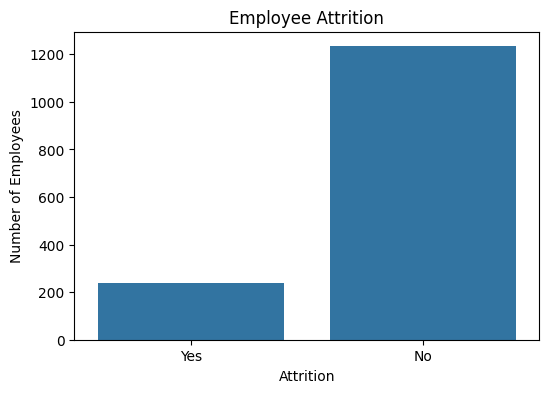

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Attrition")
plt.title("Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

## 6. Attrition by Department

This visualization compares employee attrition across different departments to identify which departments have more employees leaving the organization.

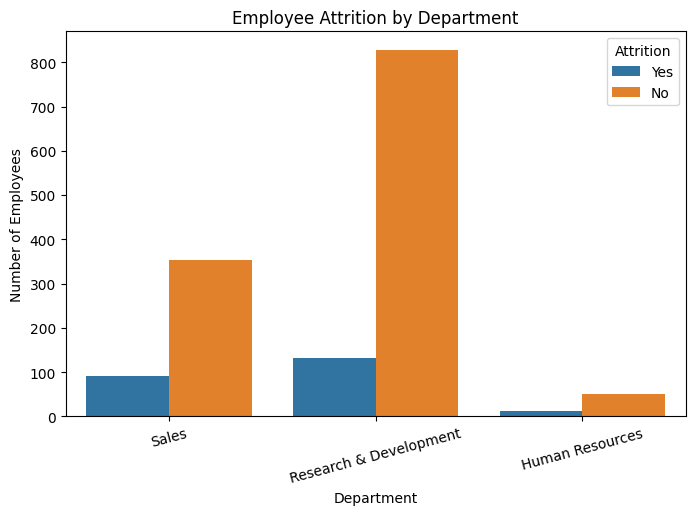

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Department",hue="Attrition")
plt.title("Employee Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=15)
plt.show()

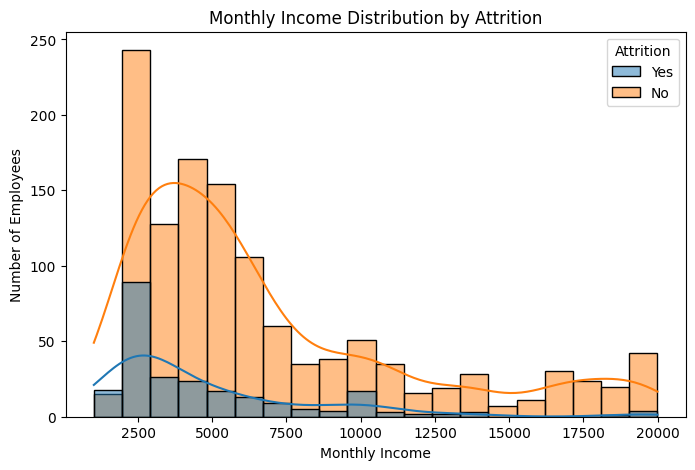

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,
x="MonthlyIncome",
             hue="Attrition", kde=True)
plt.title("Monthly Income Distribution by Attrition")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")
plt.show()

## 7. Attrition by Age

Age can be an important factor in employee retention. This analysis compares the age distribution of employees who stayed and those who left.

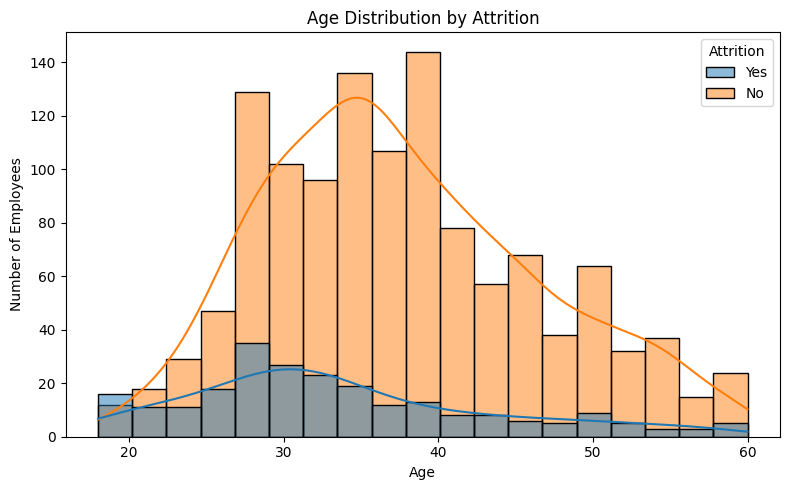

In [35]:
plt.figure(figsize=(8,5))
ax=sns.histplot(data=df,x="Age",hue="Attrition",kde=True)
ax.set_title("Age Distribution by Attrition")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Employees")
plt.tight_layout()
plt.show()

## 8. Attrition and Overtime

Working overtime may influence employee satisfaction and retention. This visualization compares attrition among employees who work overtime and those who do not.

In [36]:
import importlib
import matplotlib.pyplot as plt
plt=importlib.reload(plt)

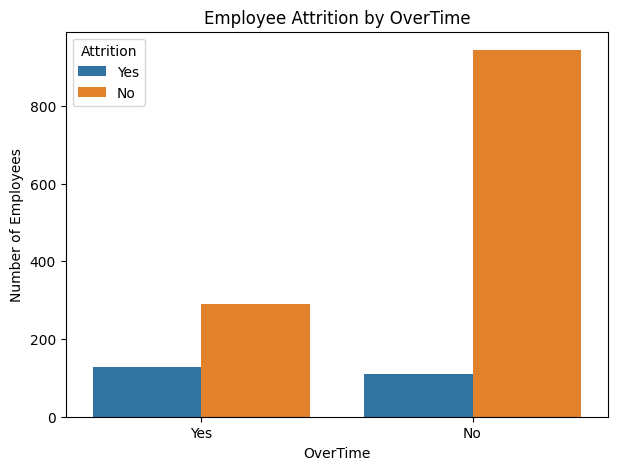

In [37]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="OverTime", hue="Attrition")
plt.title("Employee Attrition by OverTime")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.show()

## 9. Job Satisfaction & Attrition

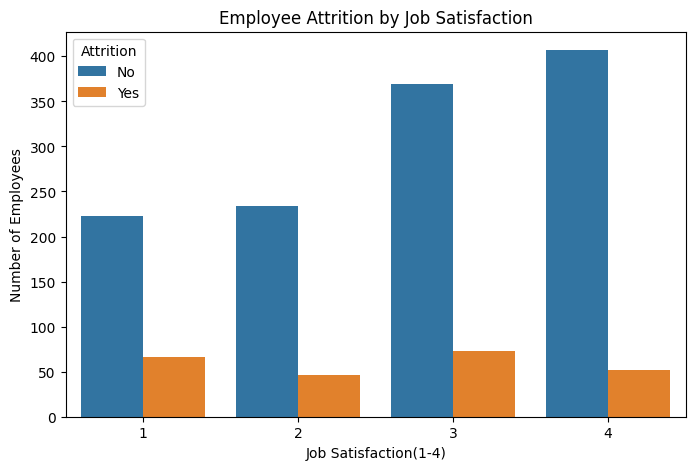

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="JobSatisfaction", hue="Attrition")
plt.title("Employee Attrition by Job Satisfaction")
plt.xlabel("Job Satisfaction(1-4)")
plt.ylabel("Number of Employees")
plt.show()

## 10. Job Role & Attrition

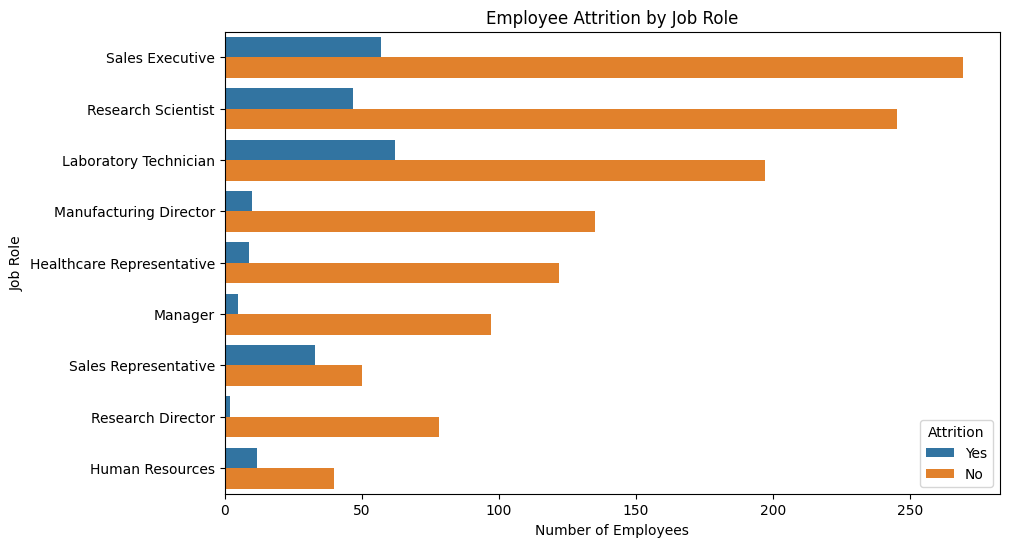

In [39]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,y="JobRole", hue="Attrition")
plt.title("Employee Attrition by Job Role")
plt.xlabel("Number of Employees")
plt.ylabel("Job Role")
plt.show()

## 11. Key Inights

The exploratory analysis provides several useful insights into employee attrition. Attrition is more common among some departments and job roles than others. Employees who work overtime show a higher level of attrition compared with employees who do not work overtime. Differences in income and age distributions can also be observed between employees who stayed and who left.

These patterns suggest that workload, job role, compensation, and employee satisfaction may be associated with employee retention.

In [40]:
df.groupby("Attrition")[["Age","MonthlyIncome","JobSatisfaction"]].mean()

,Age,MonthlyIncome,JobSatisfaction
Attrition,,,
No,37.561233,6832.739659,2.778589
Yes,33.607595,4787.092827,2.468354


## 12. Conclusion

This exploratory data analysis examined employee attrition using demographic, job-related, income, satisfaction, and work-related factors. The analysis showed that employee attrition varies across departments and job roles.
Employees who work overtime appear to have higher attrition, while employees who stayed generally have higher average income and job satisfaction.

These findings suggest that workload, compensation, job satisfaction, and employee characteristics may play an important role in employee retention. Further analysis could be performed using statistical or machine learning techniques to predict employee attrition.


## 13. Tools Used

*  Python
*  Pandas
*  Matplotlib
*  Seaborn
*  Google Colab






